/tmp/ipykernel_44955/1523096715.py:50: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))


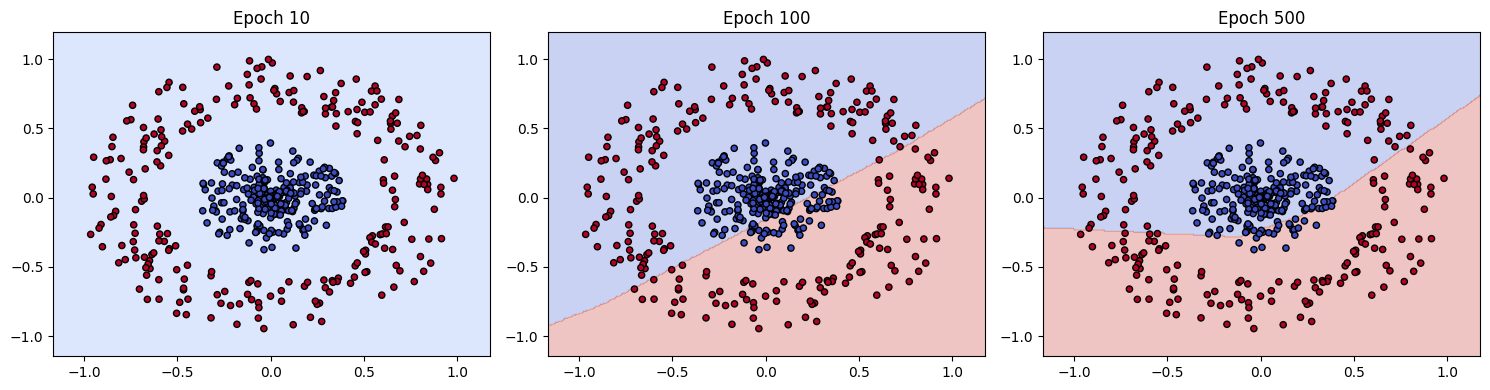

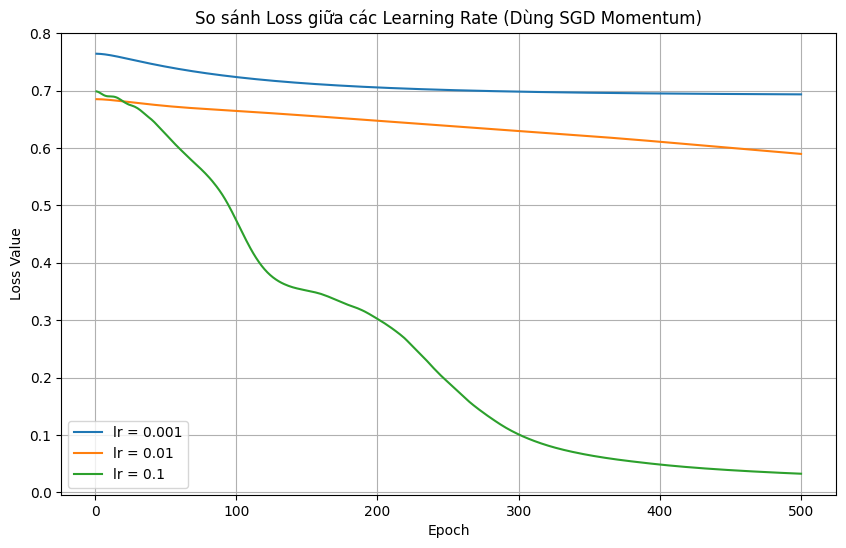

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 0. KHỞI TẠO DỮ LIỆU MẪU (Vòng tròn và vành đai)
# ---------------------------------------------------------
np.random.seed(42)
torch.manual_seed(42)

def make_circles(n_samples=500):
    # Cụm 1: Hình tròn nhỏ bên trong
    r1 = np.random.uniform(0, 0.4, n_samples // 2)
    theta1 = np.random.uniform(0, 2*np.pi, n_samples // 2)
    X1 = np.stack([r1 * np.cos(theta1), r1 * np.sin(theta1)], axis=1)

    # Cụm 2: Vành đai bên ngoài
    r2 = np.random.uniform(0.6, 1.0, n_samples // 2)
    theta2 = np.random.uniform(0, 2*np.pi, n_samples // 2)
    X2 = np.stack([r2 * np.cos(theta2), r2 * np.sin(theta2)], axis=1)

    X = np.vstack([X1, X2])
    y = np.hstack([np.zeros(n_samples // 2), np.ones(n_samples // 2)])
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32).unsqueeze(1)

X, y = make_circles()

# ---------------------------------------------------------
# 1. ĐỊNH NGHĨA MODEL CẢI TIẾN (Bỏ nn.Sigmoid ở cuối)
# ---------------------------------------------------------
class ANN_Improved(nn.Module):
    def __init__(self):
        super(ANN_Improved, self).__init__()
        self.hidden = nn.Linear(2, 4)     # Lớp ẩn có 4 nút
        self.relu = nn.ReLU()             # Hàm kích hoạt lớp ẩn
        self.output = nn.Linear(4, 1)     # Lớp đầu ra (Không chứa nn.Sigmoid)

    def forward(self, x):
        x = self.hidden(x)
        x = self.relu(x)
        x = self.output(x)
        return x

# Hàm hỗ trợ vẽ ranh giới quyết định (Decision Boundary)
def plot_decision_boundary(model, X, y, epoch, ax):
    x_min, x_max = X[:, 0].min() - 0.2, X[:, 0].max() + 0.2
    y_min, y_max = X[:, 1].min() - 0.2, X[:, 1].max() + 0.2
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))

    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    model.eval()
    with torch.no_grad():
        # Dùng torch.sigmoid vì model xuất ra logits
        pred = torch.sigmoid(model(grid)).numpy()
    Z = (pred > 0.5).astype(int).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    ax.scatter(X[:, 0], X[:, 1], c=y.squeeze(), cmap=plt.cm.coolwarm, edgecolors='k', s=20)
    ax.set_title(f"Epoch {epoch}")

# ---------------------------------------------------------
# 2. PHẦN BÀI TẬP VỀ LEARNING RATE VÀ RANH GIỚI QUYẾT ĐỊNH
# ---------------------------------------------------------
learning_rates = [0.001, 0.01, 0.1]
epochs = 500
all_losses = {}

# Khởi tạo khung hình để vẽ ranh giới quyết định cho lr = 0.01 ở các mốc epoch
fig_bound, axes_bound = plt.subplots(1, 3, figsize=(15, 4))
boundary_epochs = [10, 100, 500]
ax_idx = 0

for lr in learning_rates:
    model = ANN_Improved()
    criterion = nn.BCEWithLogitsLoss() # Sử dụng hàm Loss ổn định số học hơn
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9) # Đổi sang SGD

    loss_history = []

    for epoch in range(1, epochs + 1):
        model.train()
        # Lan truyền tiến (Forward)
        outputs = model(X)
        loss = criterion(outputs, y)

        # Lan truyền ngược & Tối ưu (Backward & Optimize)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())

        # Lưu lại ranh giới tại các epoch 10, 100, 500 cho lr lý tưởng (0.01)
        if lr == 0.01 and epoch in boundary_epochs:
            plot_decision_boundary(model, X, y, epoch, axes_bound[ax_idx])
            ax_idx += 1

    all_losses[lr] = loss_history

# Hiển thị đồ thị ranh giới quyết định
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. VẼ ĐỒ THỊ SO SÁNH 3 LEARNING RATE
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
for lr, losses in all_losses.items():
    plt.plot(range(1, epochs + 1), losses, label=f"lr = {lr}")

plt.title("So sánh Loss giữa các Learning Rate (Dùng SGD Momentum)")
plt.xlabel("Epoch")
plt.ylabel("Loss Value")
plt.legend()
plt.grid(True)
plt.show()